<a href="https://colab.research.google.com/github/he-ale/TelcoCustomerChurn/blob/main/TelcoCustomerChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telco Customer Churn**

## API Kaggle

1.   Run the first cell
2.   If you already have a Kaggle API key, select it; otherwise, you must create one in Kaggle.


In [1]:
from google.colab import files

# =========================================
# Upload kaggle.json
# =========================================
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alejandrocladeram","key":"10c818596a13b3e9b8e7a4ff04bc7aff"}'}

## Download dataset

In [2]:
import os
import jsonpickle
import zipfile

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# =========================================
# Modify the dataset you need.
# =========================================
COMPETITION_NAME = "blastchar/telco-customer-churn"
!kaggle datasets download -d $COMPETITION_NAME

# =========================================
# Unzip the folder
# =========================================
zip_file = 'telco-customer-churn' + ".zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 50.2MB/s]



## EDA

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme()

In [5]:
dataset= pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
dataset.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
i= 0
xs= []
while(len(dataset['TotalCharges'])>i):
    try:
        xs.append(float(dataset.TotalCharges[i]))
    except:
        xs.append(None)
    i+=1



In [9]:
dataset["TotalCharges"]= xs

In [10]:
del dataset['customerID']

In [11]:
dataset.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


### Basic statistics

In [16]:
dataset.describe(include="object")

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [64]:
columns = dataset.select_dtypes(include='object').columns.tolist()
limit=len(columns)

In [65]:
for column in columns:
    print(dataset.groupby(column).size())
    print("=====================================")

gender
Female    3488
Male      3555
dtype: int64
Partner
No     3641
Yes    3402
dtype: int64
Dependents
No     4933
Yes    2110
dtype: int64
PhoneService
No      682
Yes    6361
dtype: int64
MultipleLines
No                  3390
No phone service     682
Yes                 2971
dtype: int64
InternetService
DSL            2421
Fiber optic    3096
No             1526
dtype: int64
OnlineSecurity
No                     3498
No internet service    1526
Yes                    2019
dtype: int64
OnlineBackup
No                     3088
No internet service    1526
Yes                    2429
dtype: int64
DeviceProtection
No                     3095
No internet service    1526
Yes                    2422
dtype: int64
TechSupport
No                     3473
No internet service    1526
Yes                    2044
dtype: int64
StreamingTV
No                     2810
No internet service    1526
Yes                    2707
dtype: int64
StreamingMovies
No                     2785
No internet servic

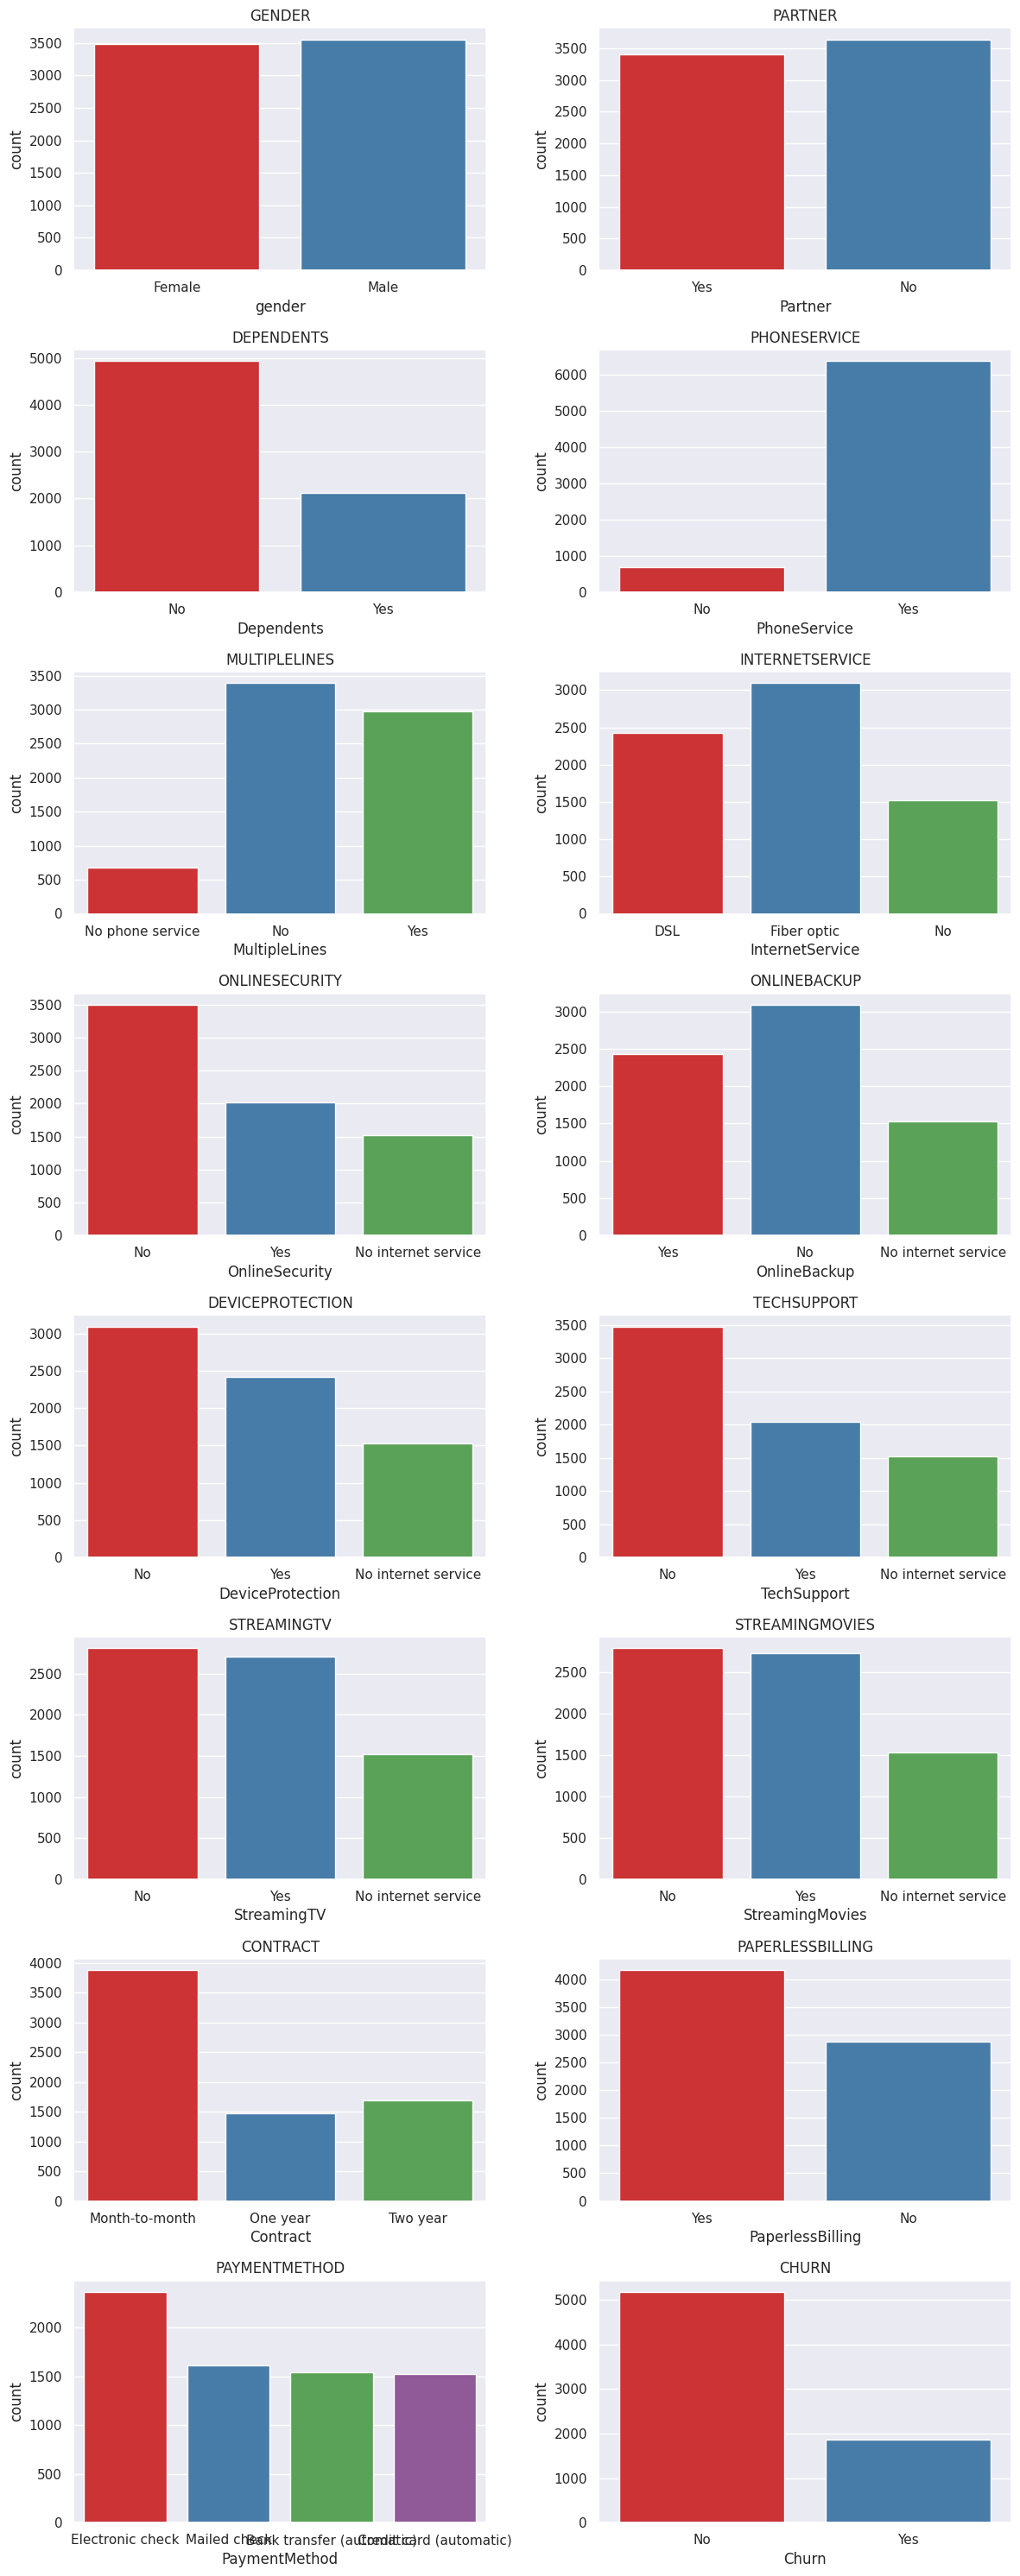

In [66]:
fig, ax= plt.subplots(ncols=2, nrows=8, figsize=(12, 30))

for k in range(limit):
    i= k//2
    j= k%2
    #ax=ax[i, j] asigna el espacio donde se dibujara
    ax[i,j]=sns.countplot(data= dataset, x=columns[k], hue=columns[k], palette='Set1', ax=ax[i, j] )
    ax[i,j].set_title(columns[k].upper())

plt.tight_layout()
plt.show()

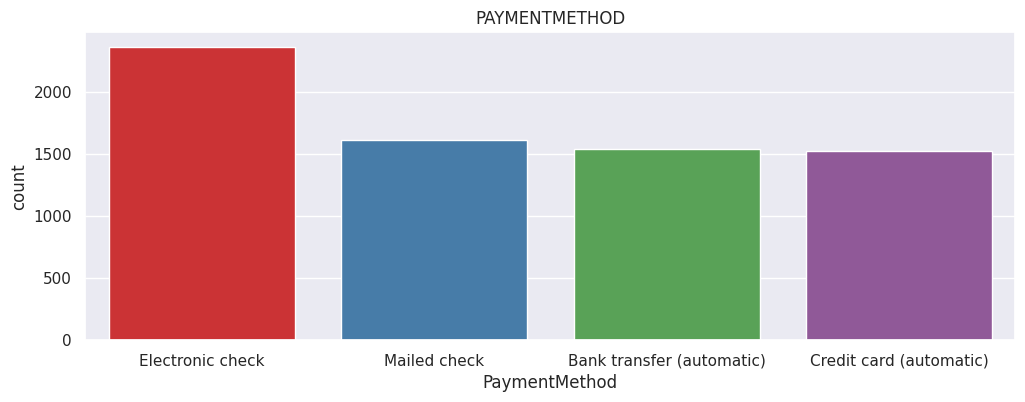

In [67]:
plt.figure(figsize=(12,4))
dataset.pipe(
    lambda data: sns.countplot(data, x="PaymentMethod", hue="PaymentMethod", palette='Set1')
)
plt.title("PaymentMethod".upper())
plt.show()

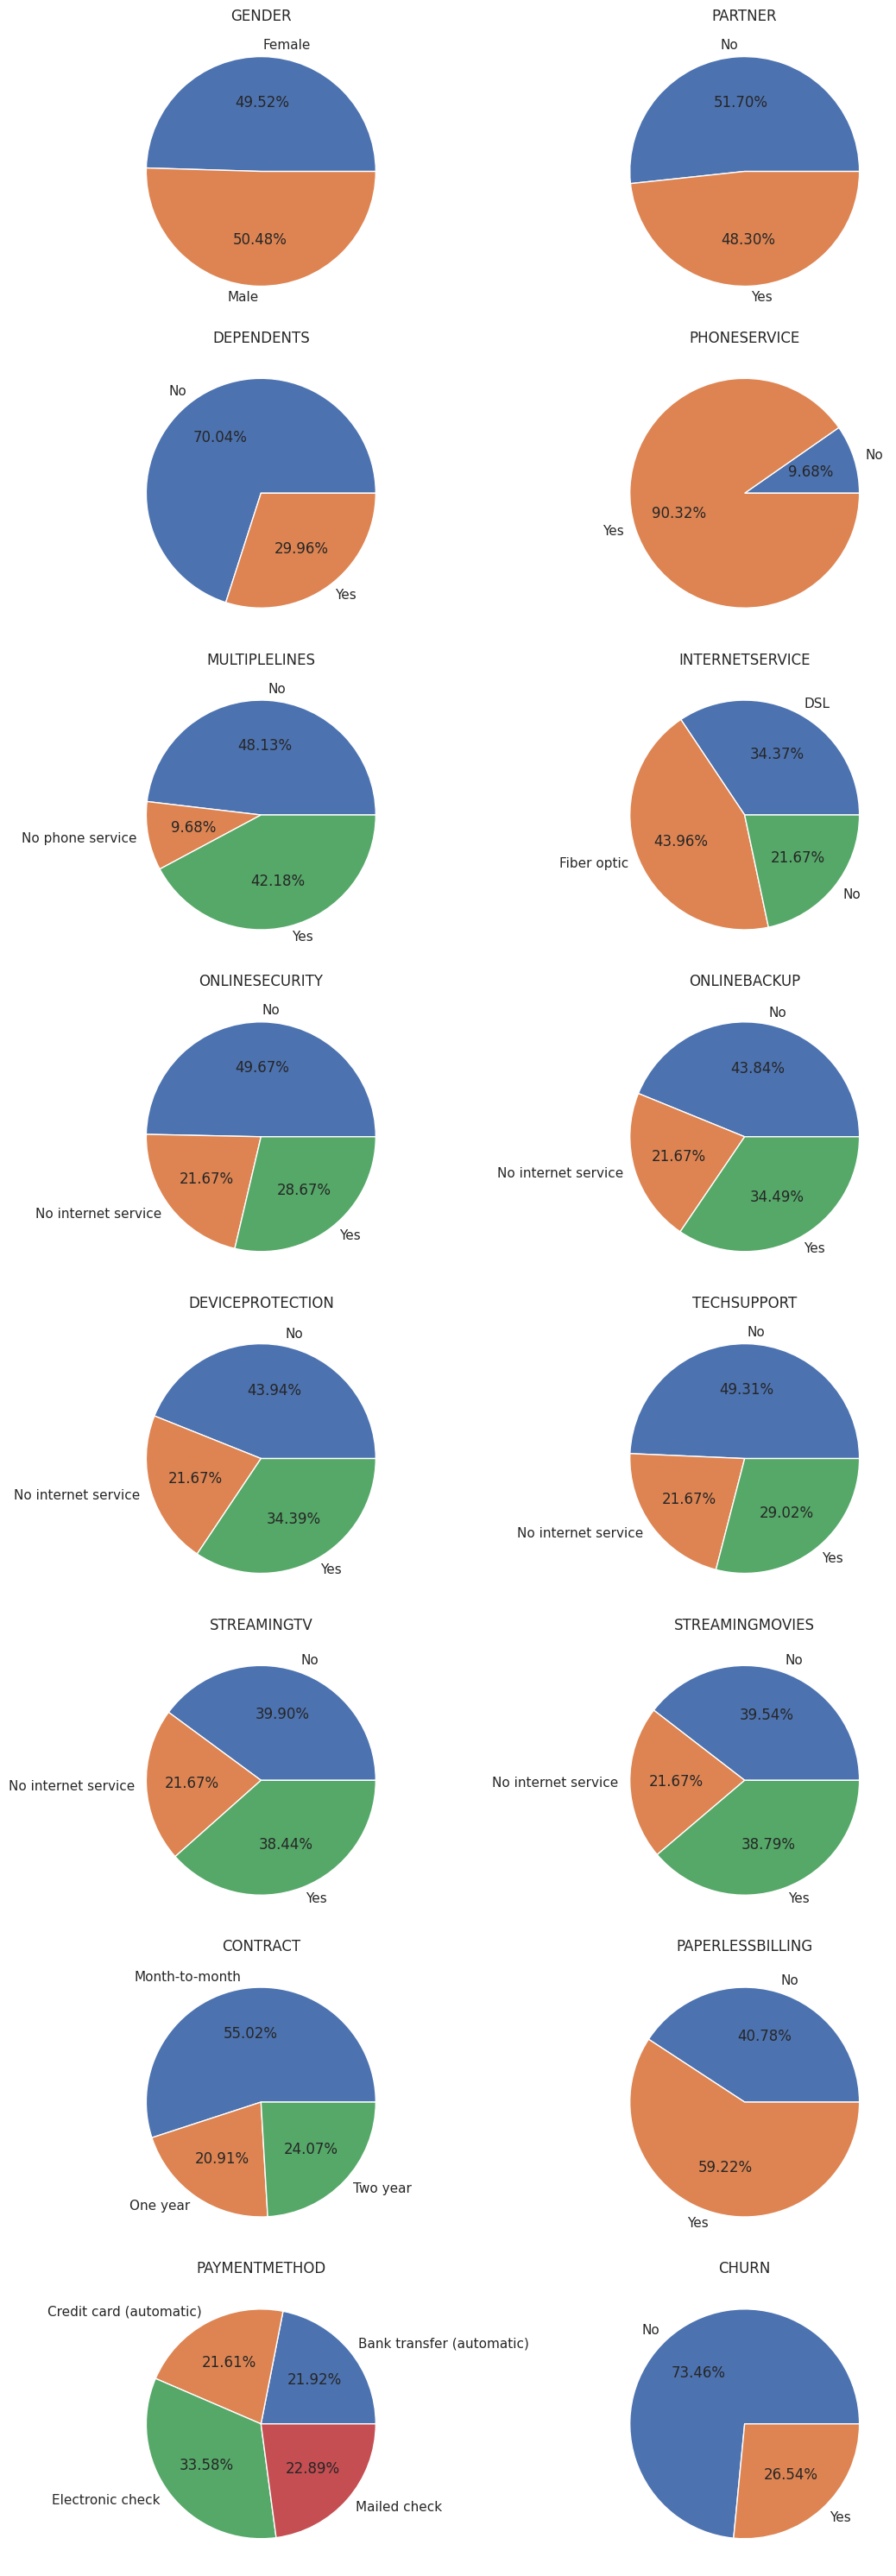

In [68]:
fig, ax= plt.subplots(ncols=2, nrows=8, figsize=(12, 30))

for k in range(limit):
    i= k//2
    j= k%2
    aux=dataset.groupby(columns[k]).size().reset_index(name="total")
    #ax=ax[i, j] asigna el espacio donde se dibujara
    ax[i, j].pie(aux["total"], labels=aux[columns[k]], autopct='%1.2f%%')
    ax[i, j].set_title(columns[k].upper())

plt.tight_layout()
plt.show()

In [17]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [19]:
numeric_columns= list(filter(lambda e1: e1[0]!="O" , zip(dataset.dtypes, dataset.columns)))
limit=len(numeric_columns)
numeric_columns

[(dtype('int64'), 'SeniorCitizen'),
 (dtype('int64'), 'tenure'),
 (dtype('float64'), 'MonthlyCharges'),
 (dtype('float64'), 'TotalCharges')]

<Axes: xlabel='SeniorCitizen', ylabel='count'>

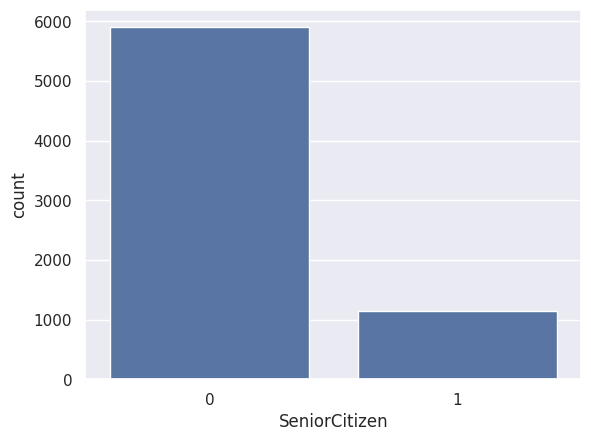

In [22]:
# TODO: ver en documentacion mas sobre esta columna
sns.countplot(data=dataset, x='SeniorCitizen')

<Axes: xlabel='tenure', ylabel='Count'>

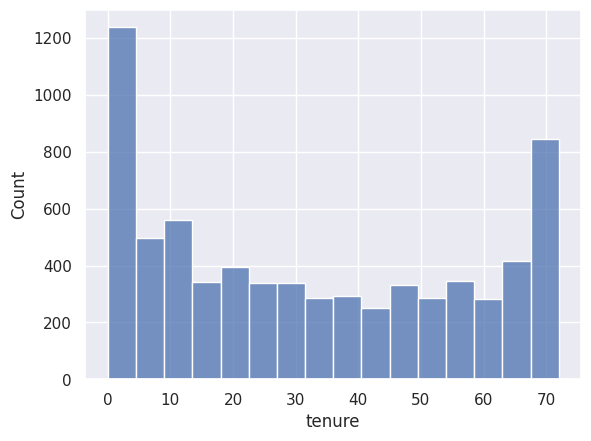

In [27]:
sns.histplot(data=dataset, x='tenure')

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

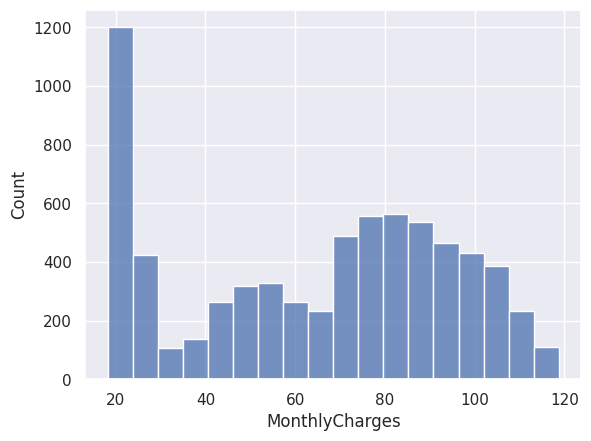

In [28]:
sns.histplot(data= dataset, x='MonthlyCharges')

<Axes: xlabel='TotalCharges', ylabel='Count'>

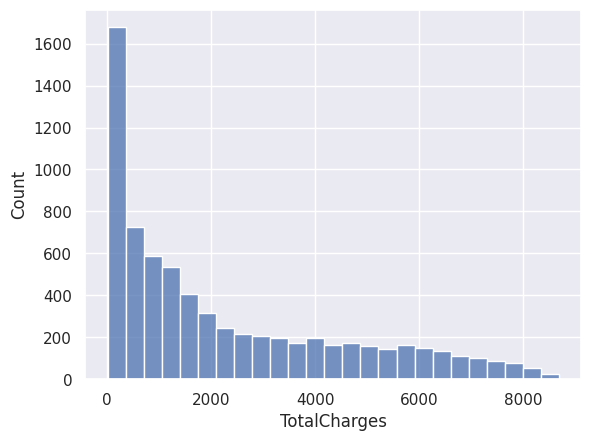

In [29]:
sns.histplot(data= dataset, x= 'TotalCharges')

<Axes: ylabel='tenure'>

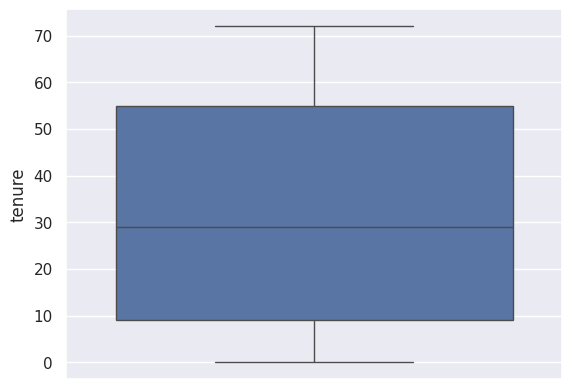

In [31]:
sns.boxplot(data= dataset, y='tenure')

<Axes: ylabel='MonthlyCharges'>

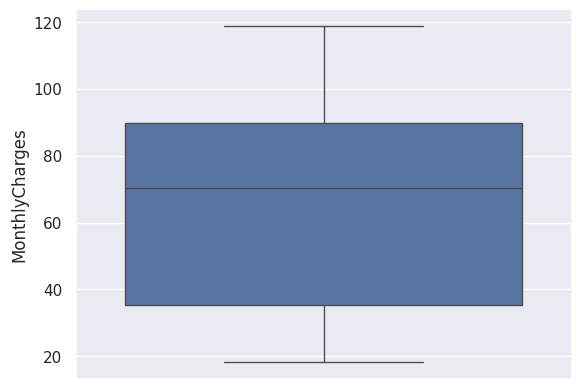

In [33]:
sns.boxplot(data= dataset, y='MonthlyCharges')

<Axes: ylabel='TotalCharges'>

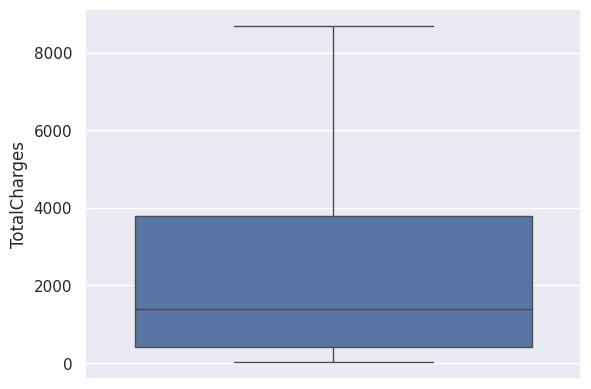

In [34]:
sns.boxplot(data= dataset, y= 'TotalCharges')

In [69]:
# TODO: comenzar a redactar en espaniol e ingles
# TODO: comenzar el analisis estadisticos si se puede
# TODO: comenzar a redactar en espaniol e ingles
# TODO: anilizar con referencia al target
# TODO: comenzar a redactar en espaniol e ingles
# TODO: comenzar con analisis estadisticos no graficos para ver relaciones
# TODO: comenzar a redactar en espaniol e ingles
# TODO: limpieza de datos
# TODO: comenzar a redactar en espaniol e ingles
# TODO: comenzar con modelos de ml
# TODO: evaluar modelos de ml
# TODO: comenzar a redactar en espaniol e ingles
# TODO: comenzar con modelos de dl
# TODO: evaluar modelos de dl
# TODO: comenzar a redactar en espaniol e ingles
# TODO: conluciones y posible informe
